## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 5 (Section 001 - Spring 2022)

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

---
# Academic integrity statement [10 points]

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# Modeling Anesthetic Drugs



**Pharmacokinetics** is the study of how drugs are distributed, absorbed and eliminated by different tissues in the body. In this quiz, and amid talks of a Covid-19 vaccine coming up, we will explore a two-compartment pharmacokinetics model. For this particular model, we will be looking at how anesthetic drugs (the things that keep you asleep during surgery) pass through your body.

In this model  the body is divided into two compartments: **the central compartment**, wich consists of the plasma (in your blood) and the tissues where the distribution of the drug is practically instantaneous; and **the peripheral compartment**, which consists of tissues where the distribution of the drug is slower.

The corresponding comparmental model can be visualized as:

<div align="center"><img src="https://i.ibb.co/vV8zC3S/PK-compartments.png" width=550px></div>

where 

1. The compartments correspond to the amounts of drug in the gastrointestinal tract (**G**), the central compartment (**C**), and the peripheral compartment (**P**). 
1. The constants describe the rate at wich the drug moves throughout the different compartments: absorption rate (**a**), distribution rate (**d**), redistribution rate (**r**) and elimination rate (**e**).

The resulting system of ODEs is as follows:

$$ \frac{dG}{dt} = -aG(t) $$

$$ \frac{dC}{dt} = aG(t) - (e + d)C(t) + rP(t) $$

$$ \frac{dP}{dt} = dC(t) - rP(t) $$

#### &#9989;&nbsp; **Question 1 [5 points]: In the cell below import all the packages you will need.**



In [ ]:
#Import packages here

In [2]:
### ANSWER ###

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp 

#### &#9989;&nbsp; **Question 2 [25 points]: In the cell below complete the derivs function for this model**

In [ ]:
def derivs(t,curr_vals,a,e,d,r):
    #Write your code here


In [3]:
### ANSWER ###

def derivs(t,curr_vals,a,e,d,r):
    G,C,P = curr_vals
    dGdt = -a*G
    dCdt = a*G - (e+d)*C + r*P
    dPdt = d*C - r*P
    return dGdt,dCdt,dPdt


#### &#9989;&nbsp; **Question 3 [25 points]: Complete the code below to solve this pharmacokinetic system using `solve_ivp()` and assuming that:** 

* In the case of oral administration of the drug, at time $t=0$ the amount of drug in the central and peripheral compartments is zero (i.e., $C(0) = P(0) = 0$) 
* That the initial dose (i.e., $G(0)$) is 500 mg
* That the absorption rate $a$ is  0.1 mg/min, that the elimination rate $e$ is 0.05 mg/min, and that distribution/redistribution are $d = 0.2$mg/min and $r = 0.1$mg/min, respectively.

Run the model for 10 hours (make sure to convert this to minutes!) and use a timestep of $\Delta t = 1$ minute.

In [ ]:
#Complete the code below

G0 = ?
C0 = ?
P0 = ?

init = [G0, C0, P0]

a = ?
e = ?
d = ?
r = ?

tmax = ?
dt = ?
time = np.arange(0, tmax + dt, dt)

sol = ?

fig = plt.figure(figsize=(10,8))
plt.plot(sol.t,sol.y[0],label='G(t)')
plt.plot(sol.t,sol.y[1],label='C(t)')
plt.plot(sol.t,sol.y[2],label='P(t)')
plt.xlabel('Time [s]')
plt.ylabel('Amount of Meds in Different Compartments (mg)')
plt.legend()

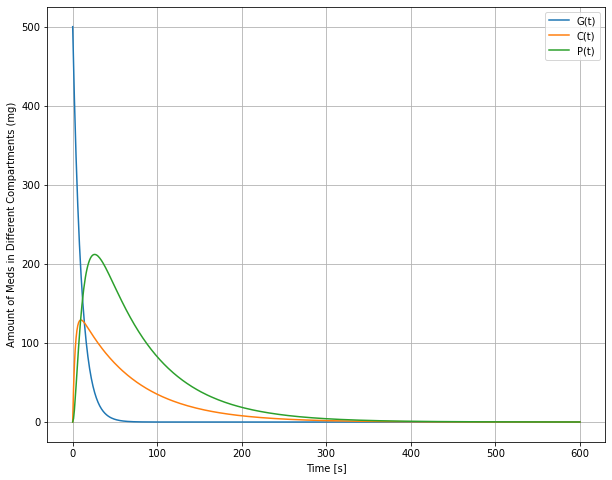

In [4]:
### ANSWER ###

G0 = 500
C0 = 0
P0 = 0

init = [G0, C0, P0]

a = 0.1
e = 0.05
d = 0.2
r = 0.1

tmax = 10*60
dt = 1
time = np.arange(0, tmax + dt, dt)

sol = solve_ivp(derivs, (0,tmax), init, t_eval = time, args=[a,e,d,r])

fig = plt.figure(figsize=(10,8))
plt.plot(sol.t,sol.y[0],label='G(t)')
plt.plot(sol.t,sol.y[1],label='C(t)')
plt.plot(sol.t,sol.y[2],label='P(t)')
plt.xlabel('Time [s]')
plt.ylabel('Amount of Meds in Different Compartments (mg)')
plt.legend()
plt.grid()



You want to learn more about this model so you can talk about it in your next research meeting. For this analysis you aren’t as interested in the GI tract.

#### &#9989;&nbsp; **Question 4 [20 points]: Vary *one* the non-GI rate parameters (e,d, or r) and see what effect it has on *one* of the non-GI compartments ($C(t)$ or $P(t)$). Make a plot showing the results. (Be sure to include all of the usual information on your plot!)**


In [ ]:
#Write code here

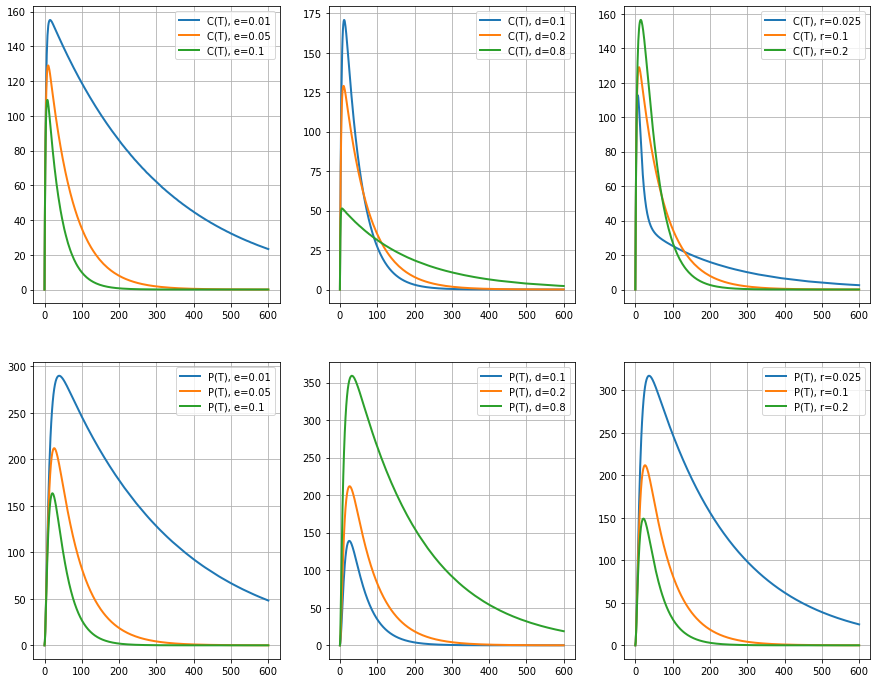

In [9]:
### ANSWER ###

#Note: the following code gives plots for variation in all three parameters and both compartments. 
#This is NOT the expectation for students.

def make_params(lists,init_vals,flag_ct,count):
    a = 0.1
    param = [a]
    for jj in range(3):
        if jj == flag_ct:
            param.append(lists[jj][count])
        else:
            param.append(init_vals[jj])
    return param

    
G0 = 500
C0 = 0
P0 = 0

init = [G0, C0, P0]

e = 0.05
e_list = [0.01,0.05,0.1]
d = 0.2
d_list = [0.1,0.2,0.8]
r = 0.1
r_list = [0.025,0.1,0.2]

all_lists = [e_list,d_list,r_list]
all_init_vals = [e,d,r]
all_strings = ["e","d","r"]

tmax = 10*60
dt = 1
time = np.arange(0, tmax + dt, dt)

fig = plt.figure(figsize=(15,12))
nx_max,ny_max = 2,3


for nx in range(nx_max):
    for ny in range(ny_max):
        plt.subplot(nx_max, ny_max, (nx)*3+ny+1)        
        for jj in range(3):
            sol = solve_ivp(derivs, (0,tmax), init, t_eval = time, args=make_params(all_lists,all_init_vals,ny,jj))
            if nx == 0:
                plt.plot(sol.t,sol.y[1],label='C(T), '+all_strings[ny]+'='+str(all_lists[ny][jj]),lw=2.0)
            else:
                plt.plot(sol.t,sol.y[2],label='P(T), '+all_strings[ny]+'='+str(all_lists[ny][jj]),lw=2.0)
        plt.legend()
        plt.grid()
plt.show()

#### &#9989;&nbsp; **Question 5 [10 points]: In the cell below, describe how the varying your chosen rate parameter affects the amount of medication in your chosen compartment. What happens when you increase the rate parameters? Decrease? Consider both the maximum value that is reached and the rate at which the medication leaves the compartment.**

*Write your response here*

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #5, and upload it there.

&#169; Copyright 2022,  Michigan State University Board of Trustees